# Model Tuning

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
from satrain.plotting import set_style
set_style()

In [4]:
def load_results(results: xr.Dataset):
    """
    Extract results from training logs.
    """

    if not isinstance(results, list):
        results = [results]

    all_res = []
    params = np.nan
    
    for path in results:
        result = xr.load_dataset(path)
        if not np.isfinite(params):
            params = result.attrs.get("num_parameters", np.nan)
        bias = result.val_bias.data
        mse = result.val_mse.data
        mae = result.val_mae.data
        corr = result.val_corrcoef.data
        
        last_ten = np.where(np.isfinite(bias))[0][-10:]
        res = xr.Dataset({
            "bias": bias[last_ten].mean(),
            "mae": mae[last_ten].mean(),
            "mse": mse[last_ten].mean(),
            "corrcoef": corr[last_ten].mean(),
        })
        all_res.append(res)
    all_res = xr.concat(all_res, dim="experiments")


    return xr.Dataset({
        "parameters": params,
        "bias_mean": all_res.bias.mean("experiments"),
        "bias_max": all_res.bias.max("experiments"),
        "bias_min": all_res.bias.min("experiments"),
        "mae_mean": all_res.mae.mean("experiments"),
        "mae_max": all_res.mae.max("experiments"),
        "mae_min": all_res.mae.min("experiments"),
        "mse_mean": all_res.mse.mean("experiments"),
        "mse_max": all_res.mse.max("experiments"),
        "mse_min": all_res.mse.min("experiments"),
        "corrcoef_mean": all_res.corrcoef.mean("experiments"),
        "corrcoef_max": all_res.corrcoef.max("experiments"),
        "corrcoef_min": all_res.corrcoef.min("experiments"),
    })

In [5]:
res_unet = load_results([
    "../models/basic_unet/netcdf_metrics/unet_gmi_gmi_gridded_xl_adamw_v01.nc",
])
res_unetx = load_results([
    "../models/basic_unet/netcdf_metrics/unet_gmi_gmi_gridded_xl_sgd_v01.nc",
])

In [6]:
from pathlib import Path

res_path = Path("../models/efficient_net_v2/netcdf_metrics/")
results_efficient_net = xr.concat([
    load_results([
        res_path / "efficient_net_v2_gmi_gmi_gridded_xl_small_pretrained_adamw_warmup_cosine_annealing_restarts_v00.nc",
    ]),
    load_results([
        res_path / "efficient_net_v2_gmi_gmi_gridded_xl_medium_pretrained_adamw_warmup_cosine_annealing_restarts_v00.nc"
    ]),
    load_results([
        res_path / "efficient_net_v2_gmi_gmi_gridded_xl_large_pretrained_adamw_warmup_cosine_annealing_restarts_v01.nc"
    ]),
],
                           dim="models")
    #"ResNet (Large)": load_results(res_

In [7]:
res = xr.load_dataset(res_path / "efficient_net_v2_gmi_gmi_gridded_xl_large_pretrained_adamw_warmup_cosine_annealing_restarts_v01.nc")
res.attrs["num_parameters"] = 25.23421e6 * 4
res.to_netcdf(res_path / "efficient_net_v2_gmi_gmi_gridded_xl_large_pretrained_adamw_warmup_cosine_annealing_restarts_v01.nc")


In [8]:
from pathlib import Path

res_path = Path("../models/encoder_decoder/netcdf_metrics/")
results_resnet = xr.concat([
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch64x128x256x512_d2_out1_bilinear_adamw_cosine_annealing_restarts_v02.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch76x152x304x608_d3_out1_bilinear_adamw_cosine_annealing_restarts_v01.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch92x184x368x736_d3x3x4x4_out1_bilinear_adamw_cosine_annealing_restarts_v02.nc",
    ]),
],
                           dim="models")

In [9]:
results_convbnrelu = xr.concat([
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_conv2dbnrelu_in13_ch92x184x368x736_d3x3x4x4_out1_bilinear_adamw_cosine_annealing_restarts_v02.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_conv2dbnrelu_in13_ch76x152x304x608_d3_out1_bilinear_adamw_cosine_annealing_restarts_v02.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch92x184x368x736_d3x3x4x4_out1_bilinear_adamw_cosine_annealing_restarts_v02.nc",
    ]),
],
                           dim="models")

In [10]:
results_resnext = xr.concat([
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch64x128x256x512_d2_out1_bilinear_adamw_cosine_annealing_restarts_v01.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch76x152x304x608_d3_out1_bilinear_adamw_cosine_annealing_restarts_v01.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch92x184x368x736_d3x3x4x4_out1_bilinear_adamw_cosine_annealing_restarts_v02.nc",
    ]),
],
                           dim="models")

In [11]:
results_swin = xr.concat([
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_swinattention_in13_ch64x128x256x512_d2_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v00.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_swinattention_in13_ch76x152x304x608_d3_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v00.nc",
    ]),
],
                           dim="models")

In [12]:
results_en2 = xr.concat([
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_efficientnetv2_in13_ch24x48x96x128_d2_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v00.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_efficientnetv2_in13_ch38x76x152x256_d3_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v00.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_efficientnetv2_in13_ch46x92x184x256_d3x3x4x4_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v00.nc",
    ]),
],
                           dim="models")

In [13]:
res_path = Path("../models/dense_encoder_decoder/netcdf_metrics/")
results_unetpp = xr.concat([
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch64x128x256x512_d2_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v02.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch76x152x304x608_d3_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v01.nc",
    ]),
    load_results([
        res_path / "encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch92x184x368x736_d3x3x4x4_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v01.nc",
    ])
],
                           dim="models")

In [14]:
res_path = Path("../models/ResNet/netcdf_metrics/")
results_resnet_seq = xr.concat([
    load_results([
        res_path / "resnet_gmi_gmi_gridded_xl_resnet_4layer_1blocks_ch32_in13_out1_adamw_warmup_cosine_annealing_restarts_v00.nc",
    ]),
    load_results([
        res_path / "resnet_gmi_gmi_gridded_xl_resnet_4layer_2blocks_ch64_in13_out1_adamw_warmup_cosine_annealing_restarts_v01.nc",
    ]),
    load_results([
        res_path / "resnet_gmi_gmi_gridded_xl_resnet_4layer_3blocks_ch96_in13_out1_adamw_warmup_cosine_annealing_restarts_v01.nc",
    ]),
],
                           dim="models")

/tmp/ipykernel_2690671/1472650230.py:23: RuntimeWarning: Mean of empty slice.
  "bias": bias[last_ten].mean(),
/home/simon/miniforge3/envs/satrain_models/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2690671/1472650230.py:24: RuntimeWarning: Mean of empty slice.
  "mae": mae[last_ten].mean(),
/tmp/ipykernel_2690671/1472650230.py:25: RuntimeWarning: Mean of empty slice.
  "mse": mse[last_ten].mean(),
/tmp/ipykernel_2690671/1472650230.py:26: RuntimeWarning: Mean of empty slice.
  "corrcoef": corr[last_ten].mean(),


In [16]:
def plot_results(axs, results, color, marker="o", alpha=0.2):
    """
    Plot results from tuning experiment.
    """
    ax = axs[0]
    ax.fill_between(results.parameters / 1e6, results.bias_min, results.bias_max, facecolor=color, alpha=0.2)
    ax.plot(results.parameters / 1e6, results.bias_mean, c=color, marker=marker)

    ax = axs[1]
    ax.fill_between(results.parameters / 1e6, results.mae_min, results.mae_max, facecolor=color, alpha=0.2)
    ax.plot(results.parameters / 1e6, results.mae_mean, c=color, marker=marker)
    
    ax = axs[2]
    ax.fill_between(results.parameters / 1e6, results.mse_min, results.mse_max, facecolor=color, alpha=0.2)
    ax.plot(results.parameters / 1e6, results.mse_mean, c=color, marker=marker)
    
    ax = axs[3]
    ax.fill_between(results.parameters / 1e6, results.corrcoef_min, results.corrcoef_max, facecolor=color, alpha=0.2)
    ax.plot(results.parameters / 1e6, results.corrcoef_mean, c=color, marker=marker)

In [17]:
from satrain.plotting import set_style
set_style()

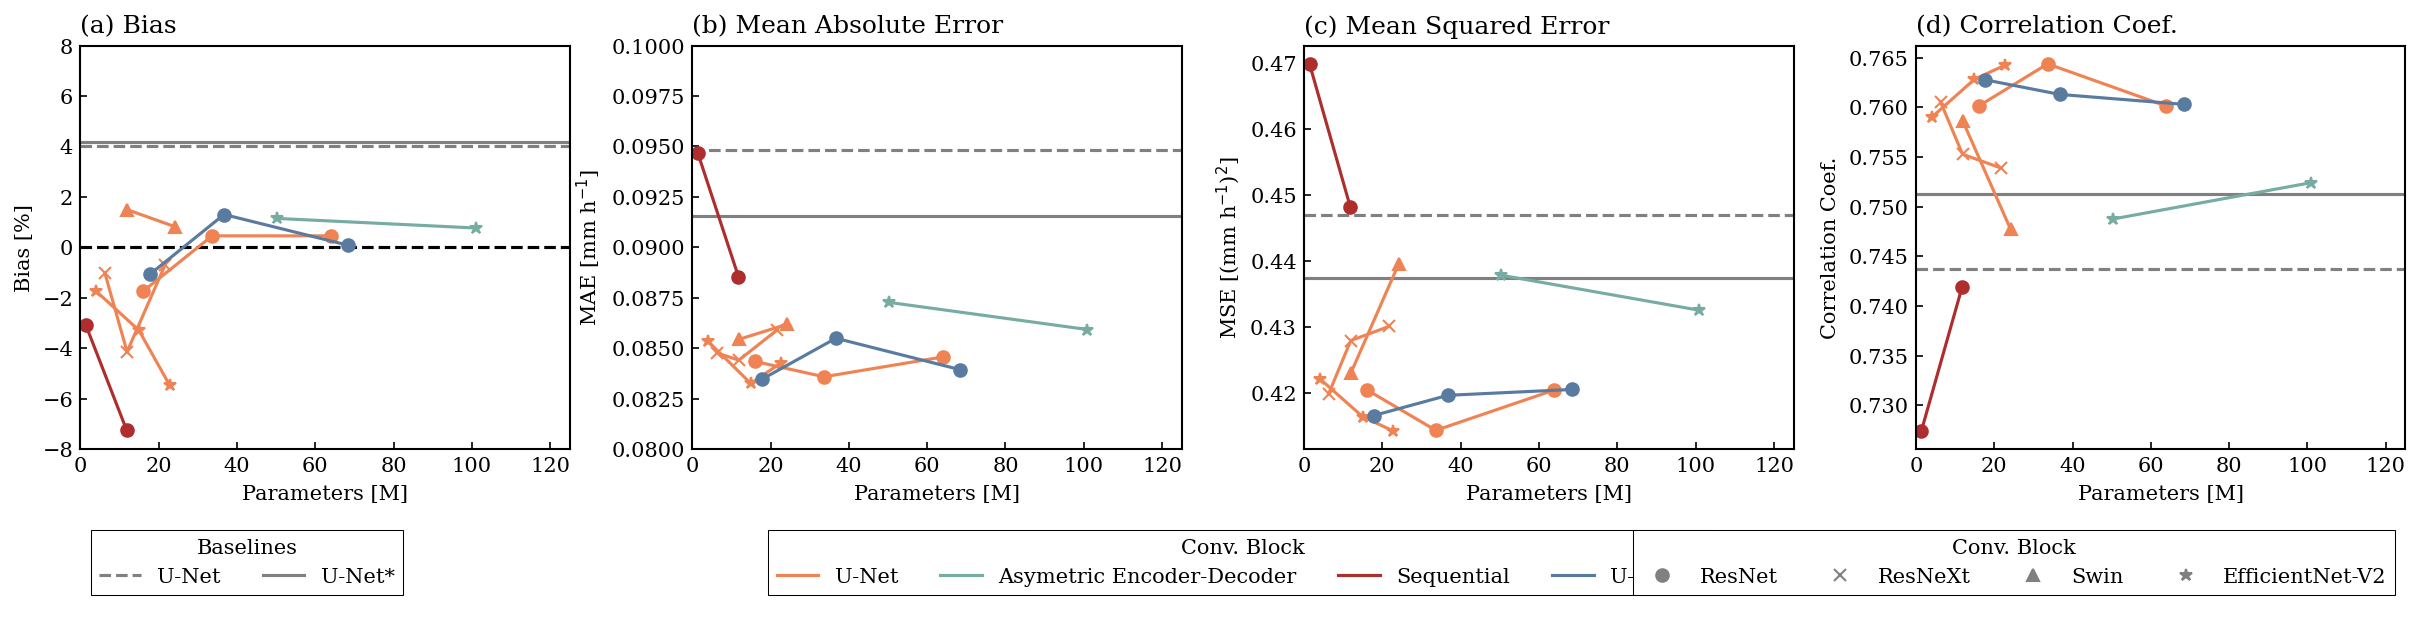

In [19]:
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
fig = plt.figure(figsize=(20, 5))
gs = GridSpec(2, 4, wspace=0.25, height_ratios=[1.0, 0.3])

axs = [fig.add_subplot(gs[0, ind]) for ind in range(4)]

markers = {
    "ResNet": "o",
    "ResNeXt": "x",
    "Swin": "^",
    "EfficientNet-V2": "*",
}

colors = {
    "U-Net": "C1",
    "Asymetric Encoder-Decoder": "C2",
    "Sequential": "C3",
    "U-Net++": "C4"
}
    


handles = []
axs[0].fill_between([-100, 200], [res_unet.bias_min.data] * 2, [res_unet.bias_max.data] * 2, facecolor="grey", alpha=0.2)
handles.append(axs[0].axhline(res_unet.bias_mean, c="grey", ls="--", label="U-Net"))
axs[0].fill_between([-100, 200], [res_unetx.bias_min.data] * 2, [res_unetx.bias_max.data] * 2, facecolor="grey", alpha=0.2)
handles.append(axs[0].axhline(res_unetx.bias_mean, c="grey", label="U-Net*"))
axs[0].set_title("(a) Bias", loc="left")
axs[0].set_ylim(-8, 8)
axs[0].axhline(0, ls="--", c="k")
axs[0].set_ylabel("Bias [%]")

axs[1].fill_between([-100, 200], [res_unet.mae_min.data] * 2, [res_unet.mae_max.data] * 2, facecolor="grey", alpha=0.2)
axs[1].axhline(res_unet.mae_mean, c="grey", ls="--")
axs[1].fill_between([-100, 200], [res_unetx.mae_min.data] * 2, [res_unetx.mae_max.data] * 2, facecolor="grey", alpha=0.2)
axs[1].axhline(res_unetx.mae_mean, c="grey")
axs[1].set_title("(b) Mean Absolute Error", loc="left")
axs[1].set_ylim(0.08, 0.1)
axs[1].set_ylabel("MAE [mm h$^{-1}$]")

axs[2].fill_between([-100, 200], [res_unet.mse_min.data] * 2, [res_unet.mse_max.data] * 2, facecolor="grey", alpha=0.2)
axs[2].axhline(res_unet.mse_mean, c="grey", ls="--")
axs[2].fill_between([-100, 200], [res_unetx.mse_min.data] * 2, [res_unetx.mse_max.data] * 2, facecolor="grey", alpha=0.2)
axs[2].axhline(res_unetx.mse_mean, c="grey")
axs[2].set_title("(c) Mean Squared Error", loc="left")
axs[2].set_ylabel("MSE [(mm h$^{-1}$)$^2$]")

axs[3].fill_between([-100, 200], [res_unet.corrcoef_min.data] * 2, [res_unet.corrcoef_max.data] * 2, facecolor="grey", alpha=0.2)
axs[3].axhline(res_unet.corrcoef_mean, c="grey", ls="--")
axs[3].fill_between([-100, 200], [res_unetx.corrcoef_min.data] * 2, [res_unetx.corrcoef_max.data] * 2, facecolor="grey", alpha=0.2)
axs[3].axhline(res_unetx.corrcoef_mean, c="grey")
axs[3].set_title("(d) Correlation Coef.", loc="left")
axs[3].set_ylabel("Correlation Coef.")

#plot_results(axs, results_convbnrelu, color=colors["U-Net"], marker=markers["U-Net"])
plot_results(axs, results_resnet, color=colors["U-Net"], marker=markers["ResNet"])
plot_results(axs, results_resnext, color=colors["U-Net"], marker=markers["ResNeXt"])
plot_results(axs, results_resnet_seq, color=colors["Sequential"], marker=markers["ResNet"])
plot_results(axs, results_efficient_net, color=colors["Asymetric Encoder-Decoder"], marker=markers["EfficientNet-V2"])
plot_results(axs, results_swin, color=colors["U-Net"], marker=markers["Swin"])
plot_results(axs, results_en2, color=colors["U-Net"], marker=markers["EfficientNet-V2"])
plot_results(axs, results_unetpp, color=colors["U-Net++"], marker=markers["ResNet"])

for ax in axs:
    ax.set_xlim(0, 125)
    ax.set_xlabel("Parameters [M]")

lax = fig.add_subplot(gs[1, :])
lax.set_axis_off()
leg = lax.legend(handles=handles, ncol=8, loc="center left", title="Baselines")
lax.add_artist(leg)

handles = [Line2D([], [], c=color, label=label) for label, color in colors.items()]
leg = lax.legend(handles=handles, ncol=8, loc="center", title="Conv. Block")
lax.add_artist(leg)

handles = [Line2D([], [], c="grey", label=label, marker=marker, ls="") for label, marker in markers.items()]
lax.legend(handles=handles, ncol=8, loc="right", title="Conv. Block")


## Calculate Inference Times

In [26]:
from satrain.evaluation import Evaluator
from satrain.input import parse_retrieval_inputs
from satrain.target import TargetConfig
target_config = TargetConfig(min_rqi=0.5)
evaluator_conus = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=[{"name": "gmi", "normalize": "minmax", "nan": -1.5}],
    download=True,
    target_config=target_config,
)

In [27]:
from time import perf_counter

n_scenes = len(evaluator_conus.target_gridded)
inds = np.random.permutation(n_scenes)[:10]

def get_execution_time(retrieval_fn, evaluator):
    total_elapsed = 0.0
    for scene_ind in inds:
        inpt = evaluator.get_input_data(scene_ind, batch_size=128, tile_size=256)
        for batch in inpt:
            start = perf_counter()
            ret = retrieval_fn(batch)
            end = perf_counter()
            total_elapsed += end - start
    return total_elapsed
        

## Encoder-Decoder Models

In [28]:
from satrain_models.config import SatRainConfig, ComputeConfig
from satrain_models.lightning import SatRainEstimationModule
from satrain_models.encoder_decoder import load_model

def load_encoder_decoder_gpu(path):
    model, satrain_cfg = load_model(path)
    lightning_module = SatRainEstimationModule(model=model)
    compute_cfg = ComputeConfig(
        approach="sgd",
        max_epochs=0,
        batch_size=16,
        num_workers=0,
        accelerator="cuda",
        devices=[0],
        precision="bf16-mixed"
    )
    return lightning_module.get_retrieval_fn(satrain_cfg, compute_cfg)
    
def load_encoder_decoder_cpu(path):
    model, satrain_cfg = load_model(path)
    lightning_module = SatRainEstimationModule(model=model)
    compute_cfg = ComputeConfig(
        approach="sgd",
        max_epochs=0,
        batch_size=16,
        num_workers=0,
        accelerator="cpu",
        devices=1,
        precision="bf16-mixed"
    )
    return lightning_module.get_retrieval_fn(satrain_cfg, compute_cfg)

In [23]:
models = [
    "/home/simon/src/satrain_models/models/encoder_decoder/models/encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch64x128x256x512_d2_out1_bilinear_adamw_cosine_annealing_restarts_v00.pt",
    "/home/simon/src/satrain_models/models/encoder_decoder/models/encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch76x152x304x608_d3_out1_bilinear_adamw_cosine_annealing_restarts_v00.pt",
    "/home/simon/src/satrain_models/models/encoder_decoder/models/encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch92x184x368x736_d3x3x4x4_out1_bilinear_adamw_cosine_annealing_restarts_v00.pt",
    "/home/simon/src/satrain_models/models/encoder_decoder/models/encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch64x128x256x512_d2_out1_bilinear_adamw_cosine_annealing_restarts_v00.pt",
    "/home/simon/src/satrain_models/models/encoder_decoder/models/encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch76x152x304x608_d3_out1_bilinear_adamw_cosine_annealing_restarts_v01.pt",
    "/home/simon/src/satrain_models/models/encoder_decoder/models/encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch92x184x368x736_d3x3x4x4_out1_bilinear_adamw_cosine_annealing_restarts_v01.pt",
    "/home/simon/src/satrain_models/models/encoder_decoder/models/encoder_decoder_gmi_gmi_gridded_xl_swinattention_in13_ch64x128x256x512_d1x2x2x3_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v01.pt",
    "/home/simon/src/satrain_models/models/encoder_decoder/models/encoder_decoder_gmi_gmi_gridded_xl_swinattention_in13_ch76x152x304x608_d3_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v00.pt"
]

In [26]:
from tqdm import tqdm
model_names = []
gpu_times = []
cpu_times = []

for model in tqdm(models):
    model_names.append(Path(model).name)
    
    retrieval = load_encoder_decoder_gpu(model)
    time = get_execution_time(retrieval, evaluator_conus)
    gpu_times.append(time)
    
    retrieval = load_encoder_decoder_cpu(model)
    time = get_execution_time(retrieval, evaluator_conus)
    cpu_times.append(time)
    
    
    
    

 75%|██████████████████████████████████████████████████████████████████████████████                          | 6/8 [04:22<01:34, 47.23s/it]/home/simon/miniforge3/envs/satrain_models/lib/python3.11/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [09:09<00:00, 68.70s/it]


In [30]:
gpu_times

[0.8708318220451474,
 1.4521905845031142,
 1.8052702574059367,
 0.8639642335474491,
 1.8399524046108127,
 2.6960716443136334,
 2.068268336355686,
 4.400196332484484]

In [28]:
cpu_times

[18.285865337587893,
 31.68734911084175,
 44.823102039285004,
 26.91910154838115,
 35.4743976444006,
 46.83392499387264,
 80.82875976525247,
 184.401375756599]

In [29]:
model_names

['encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch64x128x256x512_d2_out1_bilinear_adamw_cosine_annealing_restarts_v00.pt',
 'encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch76x152x304x608_d3_out1_bilinear_adamw_cosine_annealing_restarts_v00.pt',
 'encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch92x184x368x736_d3x3x4x4_out1_bilinear_adamw_cosine_annealing_restarts_v00.pt',
 'encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch64x128x256x512_d2_out1_bilinear_adamw_cosine_annealing_restarts_v00.pt',
 'encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch76x152x304x608_d3_out1_bilinear_adamw_cosine_annealing_restarts_v01.pt',
 'encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch92x184x368x736_d3x3x4x4_out1_bilinear_adamw_cosine_annealing_restarts_v01.pt',
 'encoder_decoder_gmi_gmi_gridded_xl_swinattention_in13_ch64x128x256x512_d1x2x2x3_out1_bilinear_adamw_warmup_cosine_annealing_restarts_v01.pt',
 'encoder_decoder_gmi_gmi_gridded_xl_swinattention_in13_ch76x152x304x608_d3_out1_bilinear_a

In [ ]:
from contextlib import contextmanager
from time import perf_counter

tot_elapse
    start = perf_counter()
    yield
    print(f"{name}: {perf_counter() - start:.3f} s")